In [ ]:
import folium

center = [10.775, 106.700]

m = folium.Map(location=center, zoom_start=13)

locations = [
    ("Bến Thành", 10.7758, 106.7009),
    ("Sân bay TSN", 10.7626, 106.6601),
    ("UBND Q1", 10.7769, 106.7009),
    ("Công viên Tao Đàn", 10.7735, 106.6920),
    ("Vincom", 10.7731, 106.7009)
]

for name, lat, lon in locations:
    folium.Marker([lat, lon], popup=name).add_to(m)

m

In [ ]:
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium
import time

geolocator = Nominatim(user_agent="geo_app", timeout=10)

center_address = "UEH, Ho Chi Minh City"
center_loc = geolocator.geocode(center_address)
center = (center_loc.latitude, center_loc.longitude)

addresses = [
    "Ben Thanh Market, Ho Chi Minh City",
    "Tan Son Nhat Airport, Ho Chi Minh City",
    "Independence Palace, Ho Chi Minh City",
    "Saigon Notre-Dame Cathedral, Ho Chi Minh City",
    "War Remnants Museum, Ho Chi Minh City",
    "Vincom Center Dong Khoi, Ho Chi Minh City",
    "Tao Dan Park, Ho Chi Minh City",
    "Bui Vien Walking Street, Ho Chi Minh City",
    "Saigon Zoo, Ho Chi Minh City",
    "Bitexco Tower, Ho Chi Minh City"
]

results = []

for addr in addresses:
    loc = geolocator.geocode(addr)
    time.sleep(1)  # tránh bị block

    if loc:
        coord = (loc.latitude, loc.longitude)
        dist = geodesic(center, coord).km

        results.append({
            "name": addr,
            "lat": loc.latitude,
            "lon": loc.longitude,
            "distance": dist
        })

m = folium.Map(location=center, zoom_start=13)

folium.Marker(center, popup="UEH", icon=folium.Icon(color='red')).add_to(m)

for r in results:
    folium.Marker(
        [r["lat"], r["lon"]],
        popup=f"{r['name']}<br>{r['distance']:.2f} km"
    ).add_to(m)

m

In [ ]:
from folium.plugins import HeatMap

heat_data = [
    [10.775,106.700],
    [10.777,106.701],
    [10.774,106.703],
    [10.780,106.699]
]

m = folium.Map(location=center, zoom_start=14)
HeatMap(heat_data).add_to(m)
m

In [ ]:
m = folium.Map(location=center, zoom_start=13)

for r in [3000,5000,10000]:
    folium.Circle(center, radius=r, color='blue', fill=True, fill_opacity=0.1).add_to(m)

m

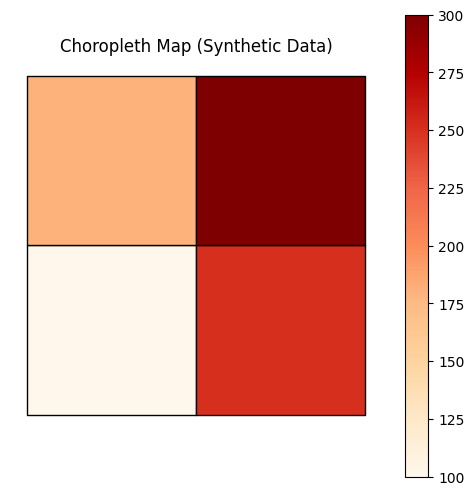

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

polygons = [
    Polygon([(0,0), (1,0), (1,1), (0,1)]),
    Polygon([(1,0), (2,0), (2,1), (1,1)]),
    Polygon([(0,1), (1,1), (1,2), (0,2)]),
    Polygon([(1,1), (2,1), (2,2), (1,2)])
]

gdf = gpd.GeoDataFrame({
    "region_id": [1, 2, 3, 4],
    "geometry": polygons
})

df = pd.DataFrame({
    "region_id": [1, 2, 3, 4],
    "value": [100, 250, 180, 300]
})

merged = gdf.merge(df, on="region_id")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
merged.plot(column="value", cmap="OrRd", legend=True, edgecolor="black", ax=ax)

plt.title("Choropleth Map (Synthetic Data)")
plt.axis("off")
plt.show()

In [ ]:
import folium
from geopy.geocoders import Nominatim
import osmnx as ox
import networkx as nx

nha = "972 An Duong Vuong, Ho Chi Minh City"

geolocator = Nominatim(user_agent="my_app")
nh_a = geolocator.geocode(nha)
toado_nha = (nh_a.latitude, nh_a.longitude)

m = folium.Map(location=toado_nha, zoom_start=15)
folium.Marker(location=toado_nha, popup=nha).add_to(m)

ox.settings.timeout = 300
ox.settings.use_cache = True
ox.settings.log_console = True

G = ox.graph_from_point(toado_nha, dist=100, network_type="walk")

stats = ox.basic_stats(G)
print(f"--- Kết quả phân tích ---")
print(f"Số nút giao: {stats['n']}")
print(f"Số đoạn đường: {stats['m']}")
print(f"Chiều dài trung bình: {stats['street_length_avg']:.2f}m")


nodes, edges = ox.graph_to_gdfs(G)


folium.GeoJson(edges).add_to(m)

m

--- Kết quả phân tích ---
Số nút giao: 12
Số đoạn đường: 22
Chiều dài trung bình: 35.70m


In [ ]:


import osmnx as ox
import networkx as nx
import folium

nha = (10.7565577, 106.6248006)
dest_point = (10.7987219,106.6374728)

G = ox.graph_from_point(nha, dist=5000, network_type='drive')

origin_node = ox.distance.nearest_nodes(G, nha[1], nha[0])
target_node = ox.distance.nearest_nodes(G, dest_point[1], dest_point[0])

route_dijkstra = nx.shortest_path(G, origin_node, target_node, weight='length', method='dijkstra')
route_astar = nx.astar_path(G, origin_node, target_node, weight='length')

m = folium.Map(location=nha, zoom_start=15)

route_coords_dijkstra = []
for node in route_dijkstra:
    lat = G.nodes[node]['y']
    lon = G.nodes[node]['x']
    route_coords_dijkstra.append((lat, lon))
folium.PolyLine(route_coords_dijkstra, color='blue', weight=3, opacity=0.6, tooltip='Dijkstra Route').add_to(m)

route_coords_astar = []
for node in route_astar:
    lat = G.nodes[node]['y']
    lon = G.nodes[node]['x']
    route_coords_astar.append((lat, lon))
folium.PolyLine(route_coords_astar, color='red', weight=3, opacity=0.6, tooltip='A* Route').add_to(m)

folium.Marker(nha, popup='Diem dau').add_to(m)
folium.Marker(dest_point, popup='Diem cuoi').add_to(m)

m

In [ ]:
import folium
from geopy.distance import geodesic
nha=[10.7565577,106.6248006]
khach=[{"ten":"A","c":[10.7532397,106.6335908]},{"ten":"B","c":[10.7551474,106.6342982]}]
xe=[{"id":"1","c":[10.7580,106.6250]},{"id":"2","c":[10.7520,106.6350]},{"id":"3","c":[10.7500,106.6200]}]
m=folium.Map(location=nha,zoom_start=15)
for k in khach:
    folium.Marker(k["c"],popup=k["ten"],icon=folium.Icon(color='red')).add_to(m)
    x=min(xe,key=lambda v:geodesic(k["c"],v["c"]).meters)
    folium.Marker(x["c"],popup=x["id"],icon=folium.Icon(color='green')).add_to(m)
    folium.PolyLine([k["c"],x["c"]]).add_to(m)
m

In [ ]:
import folium
import pandas as pd
from sklearn.cluster import KMeans
from geopy.distance import geodesic

nha = [10.7565577, 106.6248006]
ds_khach = [[10.7532397, 106.6335908], [10.7551474, 106.6342982], [10.7500, 106.6200], [10.7600, 106.6400], [10.7450, 106.6250]]

m = folium.Map(location=nha, zoom_start=14)

folium.Marker(location=nha, popup="Nha t", icon=folium.Icon(color='red', icon='home')).add_to(m)

for k in ds_khach: folium.Marker(location=k, popup='Khach hang', tooltip='Khach Hang').add_to(m)

model = KMeans(n_clusters=2, random_state=42).fit(ds_khach)
ds_kho = model.cluster_centers_

for kho in ds_kho: folium.Marker(location=kho, popup="KHO TOI UU", icon=folium.Icon(color='green', icon='star')).add_to(m)

folium.Circle(location=nha, radius=1000, color='orange', fill=True, fill_opacity=0.2).add_to(m)

m

In [ ]:
import folium
import osmnx as ox
import networkx as nx

nha = [10.7565577, 106.6248006]
diem_den = [10.7532397, 106.6335908]

G = ox.graph_from_point(nha, dist=1000, network_type='drive')

n1 = ox.distance.nearest_nodes(G, nha[1], nha[0])
n2 = ox.distance.nearest_nodes(G, diem_den[1], diem_den[0])

duong_chinh = nx.shortest_path(G, n1, n2, weight='length')
duong_phu = nx.shortest_path(G, n1, n2, weight='travel_time')

m = folium.Map(location=nha, zoom_start=15)

def ve_duong(graph, route, color, weight, map_obj):
    node_coords = [[graph.nodes[node]['y'], graph.nodes[node]['x']] for node in route]
    folium.PolyLine(node_coords, color=color, weight=weight, opacity=0.8).add_to(map_obj)

ve_duong(G, duong_chinh, 'red', 8, m)
ve_duong(G, duong_phu, 'green', 4, m)

folium.Marker(nha, popup="Diem bat dau").add_to(m)
folium.Marker(diem_den, popup="Diem den").add_to(m)

m

In [ ]:
import folium
from folium.plugins import HeatMap
ds_don = [[10.756, 106.624], [10.757, 106.625], [10.755, 106.623], [10.753, 106.633], [10.753, 106.634]]
m = folium.Map(location=[10.755, 106.625], zoom_start=15)
HeatMap(ds_don).add_to(m)
m

In [ ]:
import folium
from geopy.distance import geodesic
kho = [10.7565, 106.6248]
diem_giao = [[10.7532, 106.6335], [10.7551, 106.6342], [10.7500, 106.6200]]
lo_trinh = [kho] + sorted(diem_giao, key=lambda x: geodesic(kho, x).meters)
m = folium.Map(location=kho, zoom_start=15)
folium.Marker(kho, icon=folium.Icon(color='red', icon='home')).add_to(m)
for p in diem_giao: folium.Marker(p, icon=folium.Icon(color='blue')).add_to(m)
folium.PolyLine(lo_trinh, color='purple', weight=3).add_to(m)
m

In [ ]:
import folium
m = folium.Map(location=[10.756, 106.624], zoom_start=14)
l1 = folium.FeatureGroup(name='Tram dich vu').add_to(m)
folium.Marker([10.756, 106.624]).add_to(l1)
l2 = folium.FeatureGroup(name='Vung phuc vu').add_to(m)
folium.Circle([10.756, 106.624], radius=1000, fill=True).add_to(l2)
folium.LayerControl().add_to(m)
m

In [ ]:
import folium
m = folium.Map(location=[10.756, 106.624], zoom_start=15)
xe_di_chuyen = [[10.756, 106.624], [10.7565, 106.6245], [10.757, 106.625]]
for p in xe_di_chuyen: folium.CircleMarker(p, radius=7, color='green', fill=True).add_to(m)
m


In [ ]:
import folium
import osmnx as ox
from sklearn.cluster import MeanShift
nha = [10.7565577, 106.6248006]
ds_khach = [[10.7532, 106.6335], [10.7551, 106.6342], [10.7500, 106.6200], [10.7600, 106.6400], [10.7450, 106.6250], [10.7580, 106.6300]]
G = ox.graph_from_point(nha, dist=500, network_type='drive')
nodes, edges = ox.graph_to_gdfs(G)
model = MeanShift(bandwidth=0.005).fit(ds_khach)
ds_tram = model.cluster_centers_
m = folium.Map(location=nha, zoom_start=15)
folium.GeoJson(edges, style_function=lambda x: {'color':'gray', 'weight':1, 'opacity':0.3}).add_to(m)
for k in ds_khach: folium.CircleMarker(location=k, radius=3, color='blue').add_to(m)
for t in ds_tram: folium.Marker(location=t, icon=folium.Icon(color='green', icon='flash')).add_to(m)
m